# Setup
- Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
- Install TerraTorch
    - You will have to restart the session after installing terratorch (it kinda looks like an error)

In [9]:
!pip install terratorch==1.1.1
!pip install gdown tensorboard zarr earthaccess

INFO: pip is looking at multiple versions of lightning[pytorch-extra] to determine which version is compatible with other requirements. This could take a while.
  Using cached lightning-2.5.5-py3-none-any.whl.metadata (39 kB)
  Using cached lightning-2.5.4-py3-none-any.whl.metadata (39 kB)
  Using cached lightning-2.5.3-py3-none-any.whl.metadata (39 kB)
  Using cached lightning-2.5.2-py3-none-any.whl.metadata (38 kB)
  Using cached lightning-2.5.1.post0-py3-none-any.whl.metadata (39 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached rich-13.9.4-py3-none-any.whl.metadata (18 kB)
  Using cached tensorboardx-2.6.4-py3-none-any.whl.metadata (6.2 kB)
Using cached lightning-2.5.1.post0-py3-none-any.whl (819 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.4/59.4 MB 59.7 MB/s  0:00:01 eta 0:00:010:01:01
Using cached packaging-24.2-py3-none-any.whl (65 kB)
Using cached rich-13.9.4-py3-none-any.whl (242 kB)
Using cached tensorboardx-2.6.4-py3-none-any.whl (87 

# Download the HWDS dataset

In [16]:
import gdown
from pathlib import Path

hwds_google_drive_id = '1TC7JsbrSGTpS0CEvEbGp9TqtxDjAdLBG'
drive_url = f'https://drive.google.com/uc?id={hwds_google_drive_id}'
filename = '25_hwds_shapefile'

if not Path(f'{filename}.zip').exists():
  gdown.download(drive_url)
  !unzip 25_hwds_shapefile.zip

shp_path = Path(filename) / 'hls_hwds_polygons.shp'

# Load the data using geopandas

In [17]:
import geopandas as gpd
import matplotlib.pyplot as plt

gdf = gpd.read_file(shp_path)

2019-05-17


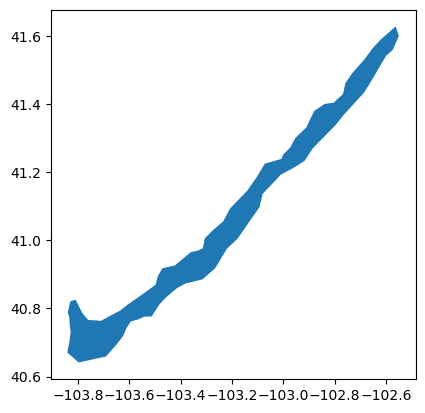

In [97]:
swath_id = '97'
swath = gdf[gdf['swathID'] == swath_id]
best_post_date = datetime(year=2019, month=5, day=24) # Update this for different swaths

swath.plot()
swath = swath.iloc[0]
print(swath['swathDate'])

# Find hls data based on polygon

In [98]:
import earthaccess

earthaccess.login()

In [99]:
from shapely import wkt
from shapely.geometry import polygon
from datetime import datetime, timedelta

geometry = polygon.orient(swath.geometry, sign=1.0)


results = earthaccess.search_data(
    short_name='HLSS30',
    polygon=list(geometry.exterior.coords),
    temporal=(post_date, post_date + timedelta(days=1))
)

In [100]:
print(len(results))
results[1]

7


Collection: {'EntryTitle': 'HLS Sentinel-2 Multi-spectral Instrument Surface Reflectance Daily Global 30m v2.0'}
Spatial coverage: {'HorizontalSpatialDomain': {'Geometry': {'GPolygons': [{'Boundary': {'Points': [{'Longitude': -102.58926867, 'Latitude': 41.40772619}, {'Longitude': -101.27696657, 'Latitude': 41.44121217}, {'Longitude': -101.31240724, 'Latitude': 42.42936087}, {'Longitude': -102.64504577, 'Latitude': 42.39470139}, {'Longitude': -102.58926867, 'Latitude': 41.40772619}]}}]}}}
Temporal coverage: {'RangeDateTime': {'BeginningDateTime': '2019-05-24T17:52:28.232Z', 'EndingDateTime': '2019-05-24T17:52:28.232Z'}}
Size(MB): 212.6760196685791
Data: ['https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B06.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B11.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.SAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B05.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B12.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.Fmask.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B10.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B07.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.VZA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B01.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.VAA.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B09.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B04.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B03.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B08.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B8A.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.B02.tif', 'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/HLSS30.020/HLS.S30.T14TKM.2019144T173909.v2.0/HLS.S30.T14TKM.2019144T173909.v2.0.SZA.tif']

In [101]:
files = earthaccess.download(
    results,
    local_path='./data/HLS'  # Specify where to save files
)

QUEUEING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/126 [00:00<?, ?it/s]

In [102]:
len(dataloader)

1250

In [103]:
from collections import OrderedDict
from torchgeo.datasets import RasterDataset, stack_samples, unbind_samples, utils
from torchgeo.samplers import RandomGeoSampler
from torch.utils.data import DataLoader


class HLSDataset(RasterDataset):
    """
    HLS dataset using TorchGeo's RasterDataset base class.
    
    Example file name:
        HLS.S30.T13TFF.2019144T173909.v2.0.B08.tif

    Bands:
        B01 ->  COASTAL
        B02 ->  BLUE
        B03 ->  GREEN
        B04 ->  RED
        B05 ->  REDEDGE1
        B06 ->  REDEDGE2
        B07 ->  REDEDGE3
        B08 ->  NIR
        B8A ->  NIR08
        B09 ->  NIR09
        B11 ->  SWIR16
        B12 ->  SWIR22
    """
    
    filename_glob = "HLS.*.tif"
    filename_regex = r"^HLS\.(?P<sensor>[SL])30\.(?P<tile>T\w+)\.(?P<date>\d+T\d+)\.v\d+\.\d+\.(?P<band>B\w+|SZA|SAA|VZA|VAA)\.tif$"
    date_format = '%Y%d%mT%H%M%S'
    
    separate_files = True
    is_image = True
    
    all_bands = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B10", "B11", "B12", "Fmask")
    rgb_bands = ('B04', 'B03', 'B02')

In [104]:
# Create dataset
dataset = HLSDataset(
    paths='./data/HLS',
    bands= ('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
)

# Spatial sampling
sampler = RandomGeoSampler(
    dataset,
    size=224,
    length=10000
)

dataloader = DataLoader(
    dataset,
    sampler=sampler,
    batch_size=8,
    collate_fn=stack_samples
)

In [105]:
for batch in dataloader:
    print(batch['image'].shape)
    break

torch.Size([8, 12, 224, 224])
